In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add the project root (ml_laboratory) to Python's search path
sys.path.append(str(Path().resolve().parent))
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)
from utils import eda_tabular

Imported successfully


In [2]:
df = pd.read_csv("../datasets/spambase.csv")

display(df.head())

print(df.shape)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


(4601, 58)


Shape: (4601, 58)

Column types:
 word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float64
word_freq_money               float64
word_freq_hp                  float64
word_freq_hpl   

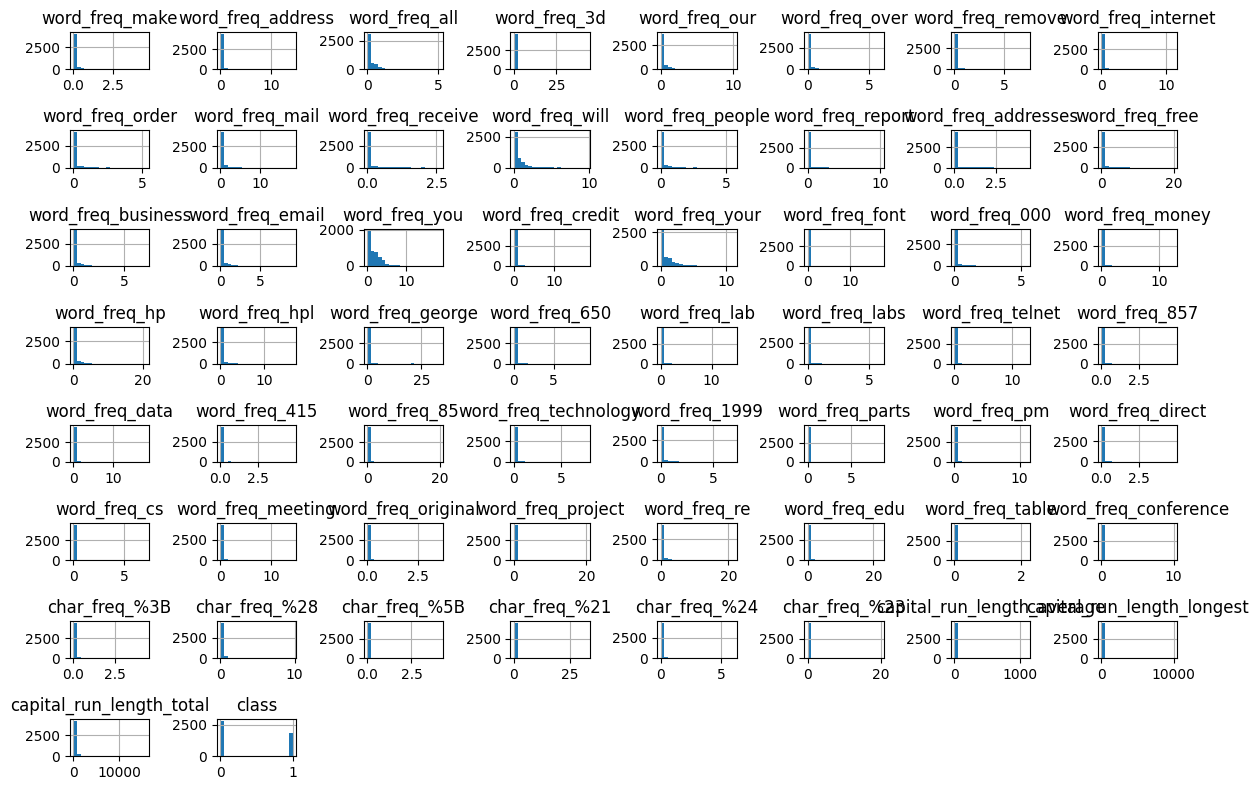

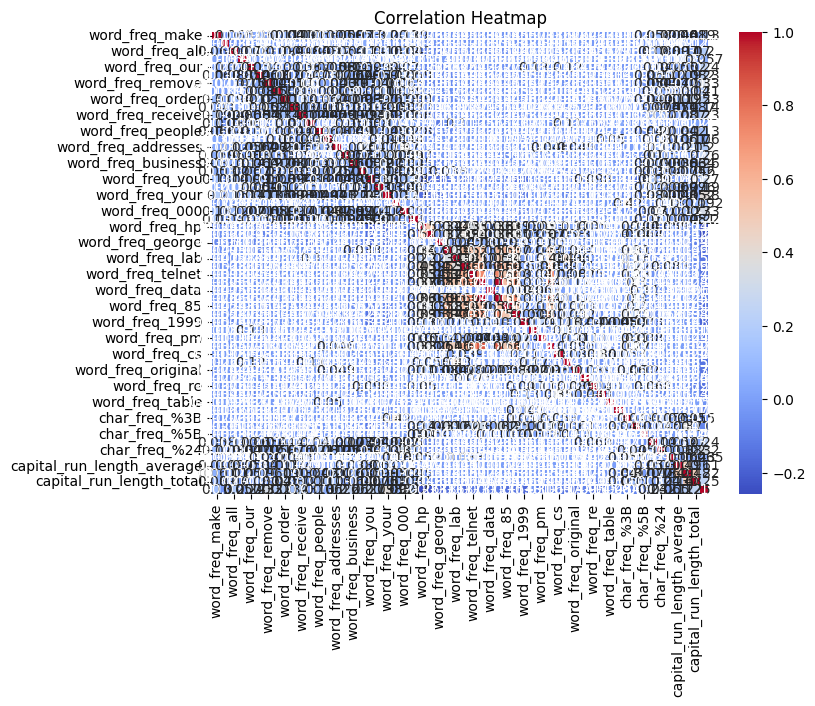

(Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
        'word_freq_our', 'word_freq_over', 'word_freq_remove',
        'word_freq_internet', 'word_freq_order', 'word_freq_mail',
        'word_freq_receive', 'word_freq_will', 'word_freq_people',
        'word_freq_report', 'word_freq_addresses', 'word_freq_free',
        'word_freq_business', 'word_freq_email', 'word_freq_you',
        'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
        'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
        'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
        'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
        'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
        'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
        'word_freq_original', 'word_freq_project', 'word_freq_re',
        'word_freq_edu', 'word_freq_table', 'word_freq

In [7]:
eda_tabular(df)

In [17]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)


In [11]:
print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy : 0.9196525515743756
Precision: 0.9316939890710383
Recall   : 0.8743589743589744
F1 Score : 0.9021164021164021
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       531
           1       0.93      0.87      0.90       390

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



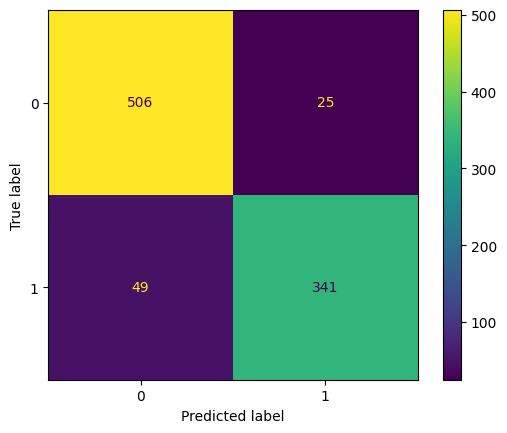

In [12]:
ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    cmap = "viridis"
)

plt.show()

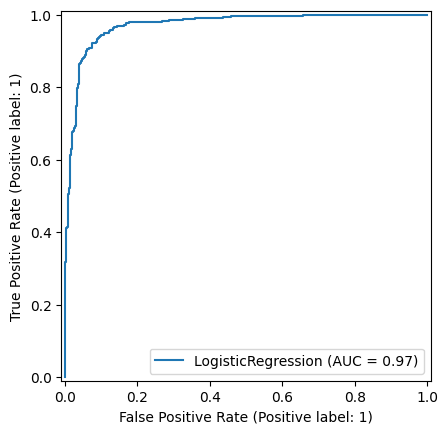

In [13]:
RocCurveDisplay.from_estimator(
    log_model,
    X_test,
    y_test
)

plt.show()

In [23]:
params = {
    "C":[0.01,0.1,1,10],
    "solver":["liblinear","saga"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=10000),
    params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 10, 'solver': 'liblinear'}
0.9258152173913043


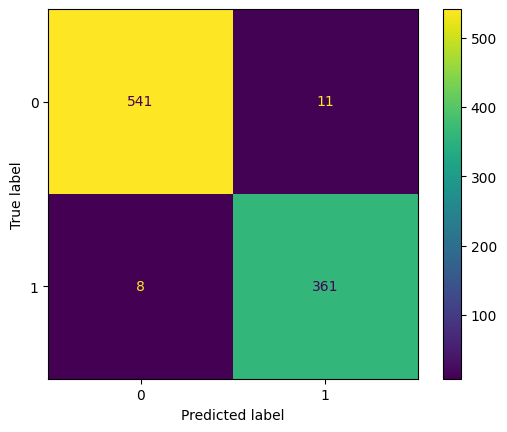

In [24]:
ConfusionMatrixDisplay.from_estimator(
    grid,
    X_test,
    y_test,
    cmap = "viridis"
)

plt.show()

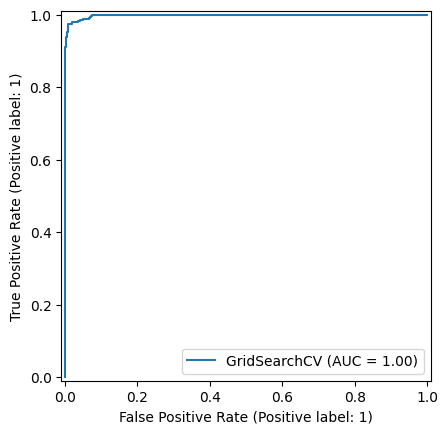

In [25]:
RocCurveDisplay.from_estimator(
    grid,
    X_test,
    y_test
)

plt.show()

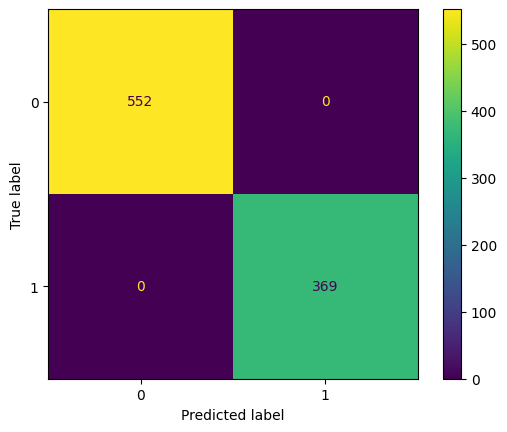

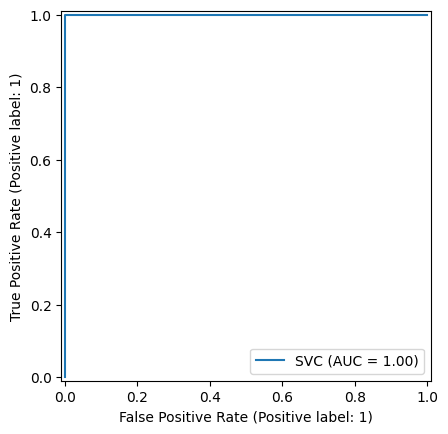

In [30]:
svm = SVC(kernel="linear")

svm.fit(X_train,y_train)
y_test = svm.predict(X_test)
ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test,
    y_test
)
plt.show()
RocCurveDisplay.from_estimator(
    svm,
    X_test,
    y_test
)

plt.show()

In [ ]:
print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))

Accuracy : 0.9250814332247557
Precision: 0.9349593495934959
Recall   : 0.8846153846153846
F1 Score : 0.9090909090909091


In [21]:
kernels = [
    "linear",
    "poly",
    "rbf",
    "sigmoid"
]

for kernel in kernels:

    model = SVC(kernel=kernel)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    print("="*40)

    print(kernel.upper())

    print("Accuracy :",accuracy_score(y_test,pred))

    print("F1 :",f1_score(y_test,pred))

LINEAR
Accuracy : 0.9250814332247557
F1 : 0.9090909090909091
POLY
Accuracy : 0.7643865363735071
F1 : 0.629059829059829
RBF
Accuracy : 0.9348534201954397
F1 : 0.9206349206349206
SIGMOID
Accuracy : 0.8892508143322475
F1 : 0.8664921465968587


In [28]:
params = {
    "kernel":["linear","poly","rbf","sigmoid"],
    "C":[0.1,1,10,100],
    "gamma":["scale","auto"],
    "degree":[2,3,4]
}

grid_svc = GridSearchCV(
    SVC(max_iter=5000),
    params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svc.fit(X_train,y_train)

print(grid_svc.best_params_)

print(grid_svc.best_score_)

/home/jk/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/jk/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/jk/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/jk/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/jk/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (

{'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
0.93125


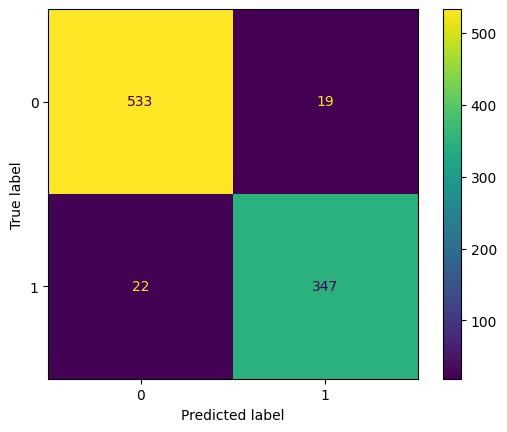

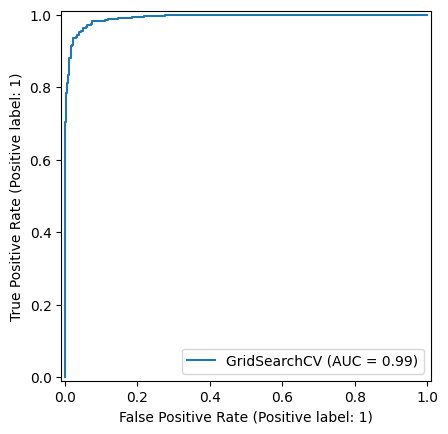

In [29]:
ConfusionMatrixDisplay.from_estimator(
    grid_svc,
    X_test, 
    y_test
)
plt.show()

RocCurveDisplay.from_estimator(
    grid_svc,
    X_test,
    y_test
)
plt.show()

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "SVM": SVC(kernel="rbf")
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    print(name)

    print(scores)

    print("Average:", scores.mean())

Logistic Regression
[0.91856678 0.92826087 0.92934783 0.94021739 0.84021739]
Average: 0.9113220507010338
SVM
[0.93268187 0.93369565 0.95       0.94891304 0.85      ]
Average: 0.9230581126374922


In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "SVM": SVC(kernel="rbf")
}

for name, model in models.items():

    model.fit(X_train,y_train)

    train_acc = model.score(X_train,y_train)

    test_acc = model.score(X_test,y_test)

    print(name)

    print("Train:",train_acc)

    print("Test :",test_acc)

Logistic Regression
Train: 0.9277173913043478
Test : 0.9196525515743756
SVM
Train: 0.9453804347826087
Test : 0.9348534201954397
